In [1]:
pip install ucimlrepo

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier
from matplotlib.colors import ListedColormap

In [3]:
from ucimlrepo import fetch_ucirepo
from sklearn.preprocessing import StandardScaler

wine = fetch_ucirepo(id=109)
X = wine.data.features
y = wine.data.targets

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Original features (X) shape:", X.shape)
print("Original targets (y) shape:", y.shape)
print("Shape of standardized features (X_scaled):", X_scaled.shape)

Original features (X) shape: (178, 13)
Original targets (y) shape: (178, 1)
Shape of standardized features (X_scaled): (178, 13)


In [4]:
X

,Alcohol,Malicacid,Ash,Alcalinity_of_ash,Magnesium,Total_phenols,Flavanoids,Nonflavanoid_phenols,Proanthocyanins,Color_intensity,Hue,0D280_0D315_of_diluted_wines,Proline
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735
...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740
174,13.40,3.91,2.48,23.0,102,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750
175,13.27,4.28,2.26,20.0,120,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835
176,13.17,2.59,2.37,20.0,120,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840


Full dataset logistic reg

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y.values.ravel(), test_size=0.2, random_state=42)
log_reg_full = LogisticRegression(max_iter=1000, random_state=42)
log_reg_full.fit(X_train, y_train)

y_pred_full = log_reg_full.predict(X_test)
acc_full = accuracy_score(y_test, y_pred_full)
f1_full = f1_score(y_test, y_pred_full, average='weighted')

print(f"Full Feature Accuracy: {acc_full:.4f}")
print(f"Full Feature F1 Score: {f1_full:.4f}")

Full Feature Accuracy: 1.0000
Full Feature F1 Score: 1.0000


LDA 2 features

LDA (2-Component) Accuracy: 1.0000
LDA (2-Component) F1 Score: 1.0000


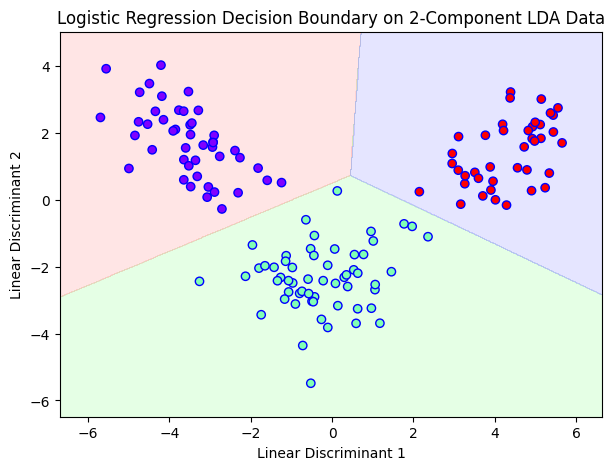

In [8]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# Fix: Transform the data using LDA with 2 components
lda_2 = LinearDiscriminantAnalysis(n_components=2)
X_train_lda_2 = lda_2.fit_transform(X_train, y_train)
X_test_lda_2 = lda_2.transform(X_test)
y_train_lda_2 = y_train
y_test_lda_2 = y_test

# Train the classifier
lda_2_classifier = LogisticRegression(random_state=42)
lda_2_classifier.fit(X_train_lda_2, y_train_lda_2)

# Evaluate the classifier
y_pred_lda_2 = lda_2_classifier.predict(X_test_lda_2)
accuracy = accuracy_score(y_test_lda_2, y_pred_lda_2)
f1 = f1_score(y_test_lda_2, y_pred_lda_2, average='weighted')

print(f"LDA (2-Component) Accuracy: {accuracy:.4f}")
print(f"LDA (2-Component) F1 Score: {f1:.4f}")

# Plotting logic
x_min, x_max = X_train_lda_2[:, 0].min() - 1, X_train_lda_2[:, 0].max() + 1
y_min, y_max = X_train_lda_2[:, 1].min() - 1, X_train_lda_2[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

Z = lda_2_classifier.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)
cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'])

plt.figure(figsize=(7,5))
plt.contourf(xx, yy, Z, alpha=0.3, cmap=cmap_light)
plt.scatter(X_train_lda_2[:, 0], X_train_lda_2[:, 1], c=y_train_lda_2, cmap='rainbow', edgecolors='b')
plt.xlabel('Linear Discriminant 1')
plt.ylabel('Linear Discriminant 2')
plt.title('Logistic Regression Decision Boundary on 2-Component LDA Data')
plt.show()

LDA 1 feature

LDA (1-Component) Accuracy: 0.8889
LDA (1-Component) F1 Score: 0.8894


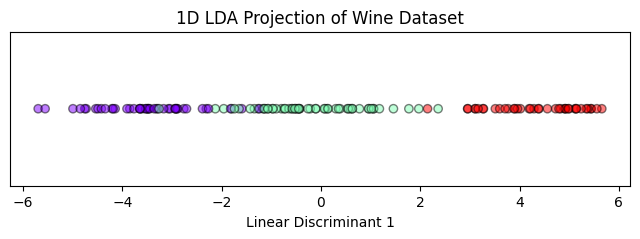

In [9]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

# 1. Apply LDA for 1 component
lda_1 = LinearDiscriminantAnalysis(n_components=1)
X_train_lda_1 = lda_1.fit_transform(X_train, y_train)
X_test_lda_1 = lda_1.transform(X_test)

# 2. Train Logistic Regression on 1D data
log_reg_lda_1 = LogisticRegression(random_state=42)
log_reg_lda_1.fit(X_train_lda_1, y_train)

# 3. Evaluation
y_pred_lda_1 = log_reg_lda_1.predict(X_test_lda_1)
accuracy_lda_1 = accuracy_score(y_test, y_pred_lda_1)
f1_lda_1 = f1_score(y_test, y_pred_lda_1, average='weighted')

print(f"LDA (1-Component) Accuracy: {accuracy_lda_1:.4f}")
print(f"LDA (1-Component) F1 Score: {f1_lda_1:.4f}")

# 4. Visualization (1D strip plot)
plt.figure(figsize=(8, 2))
plt.scatter(X_train_lda_1, np.zeros_like(X_train_lda_1), c=y_train, cmap='rainbow', alpha=0.5, edgecolors='k')
plt.title('1D LDA Projection of Wine Dataset')
plt.xlabel('Linear Discriminant 1')
plt.yticks([])
plt.show()

### 1. Accuracy & F1-Score Comparison
- **All Features (13D):** 100% accuracy (1.00). The model has all the information needed to draw clear boundaries between clusters.
- **LDA (2D):** 100% accuracy (1.00). This shows we can run on 2 features and the performance would be sustained (possible overfitting).
- **LDA (1D):** Significant drop (~0.89). Single feature exhibits overlapping and lack of clear judgement.

### 2. LDA vs. PCA: The Core Difference
- **PCA (Unsupervised):** Label are unavailable. It just looks for variance in data. Two similar classes can wind up together.
- **LDA (Supervised):** It can segregate classes since it knows their labels. It's built for classification and can correct higher overlapping degree.

### 3. Classification Report
- **Class Separability:** In the 2D LDA projection, the clusters are extremely distinct with clear 'air' between them. Even in 1D, the groups remain mostly clustered, though the fringes begin to bleed into each other.
- **Dimensionality Impact:** We've achieved a massive 85% reduction in data size (from 13 to 2 features) with zero loss in accuracy. This makes the model faster, prevents overfitting, and allows for easy 2D visualization.
- **Performance Trade-off:** The jump from 2D to 1D highlights the 'elbow' point; 2 components are the sweet spot for this dataset. LDA successfully captured the 'discriminative' information that simpler methods might have missed.